# **연수구 지방세 징수 데이터 분석 (NanumBarunGothicBold 적용)**
 
**같은 경로의 `NanumBarunGothicBold.ttf`를 강제 로드해서 한글 깨짐 0%**로 만든다.  
그리고 흐름은 딱 4단계:

> 로드 → 정제 → 분석 → 시각화 → 저장

---

## 핵심 설계

- 폰트: `NanumBarunGothicBold.ttf` (현재 실행 경로 기준)
- 단위: **십억 원**으로 스케일링 (가독성 ↑)
- 그래프:
  - 세목별 금액 비교 (부과 / 수납 / 미수납)
  - 징수율
  - 부과금액 비중 (파이)
  - 미수납 TOP

---

## 실행 코드

[INFO] Font Loaded: NanumBarunGothic
[INFO] Encoding: euc-kr

===== 핵심 KPI =====
총 부과금액: 927,542,947,000
총 수납금액: 907,359,932,000
총 미수납 : 19,122,868,000
징수율     : 97.82%
[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\01_compare.png


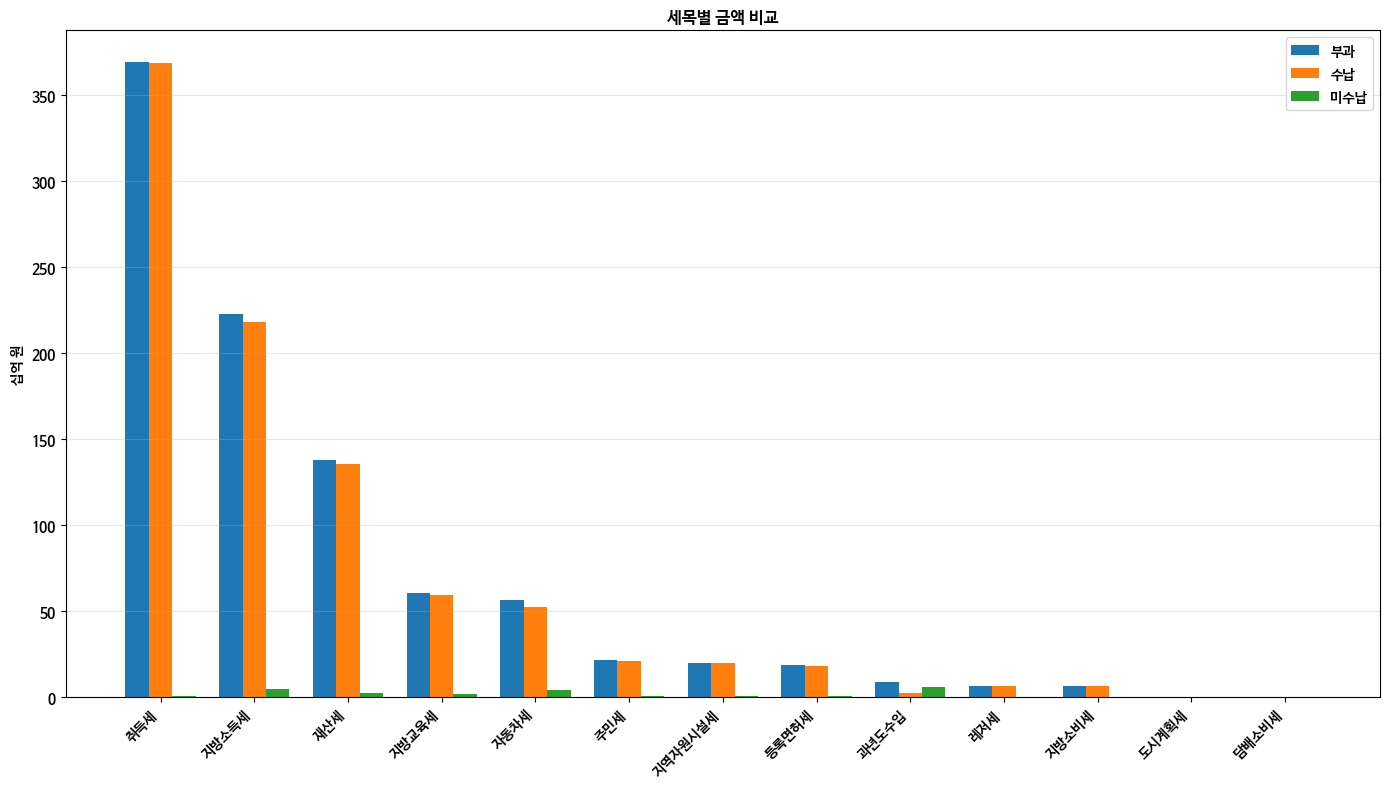

[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\02_rate.png


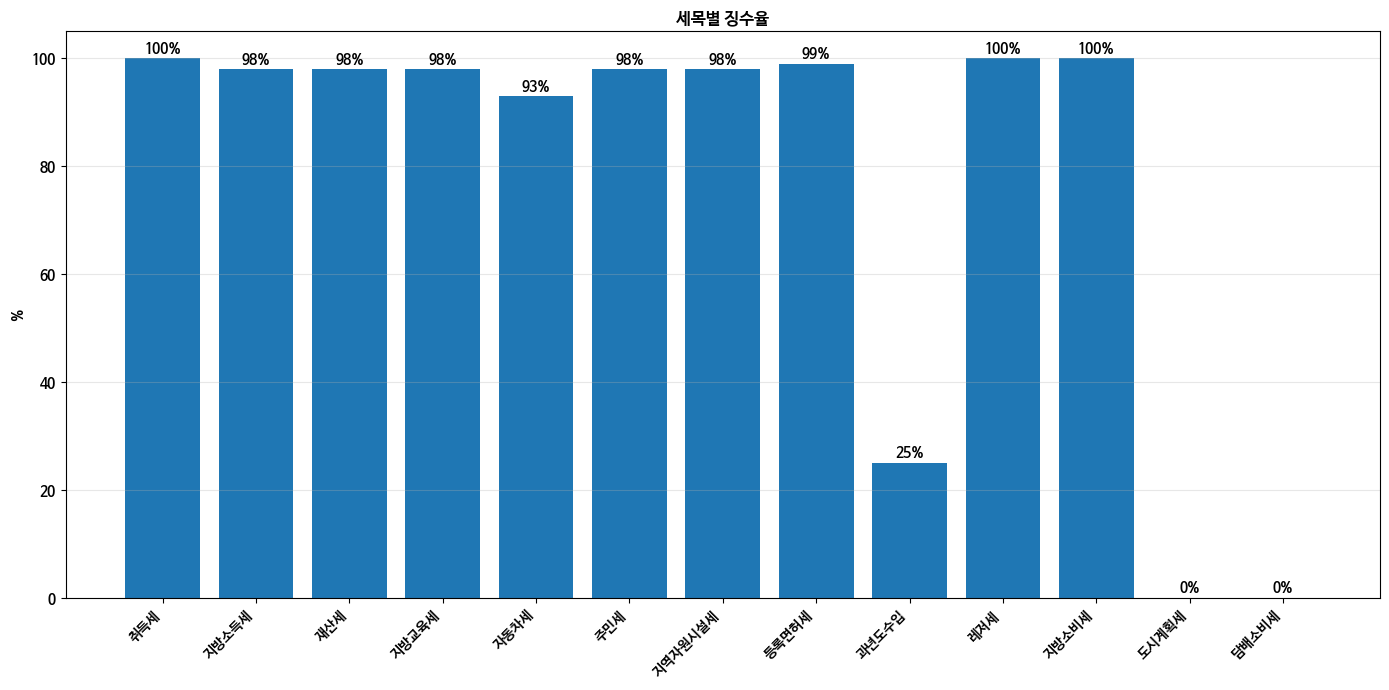

[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\03_pie.png


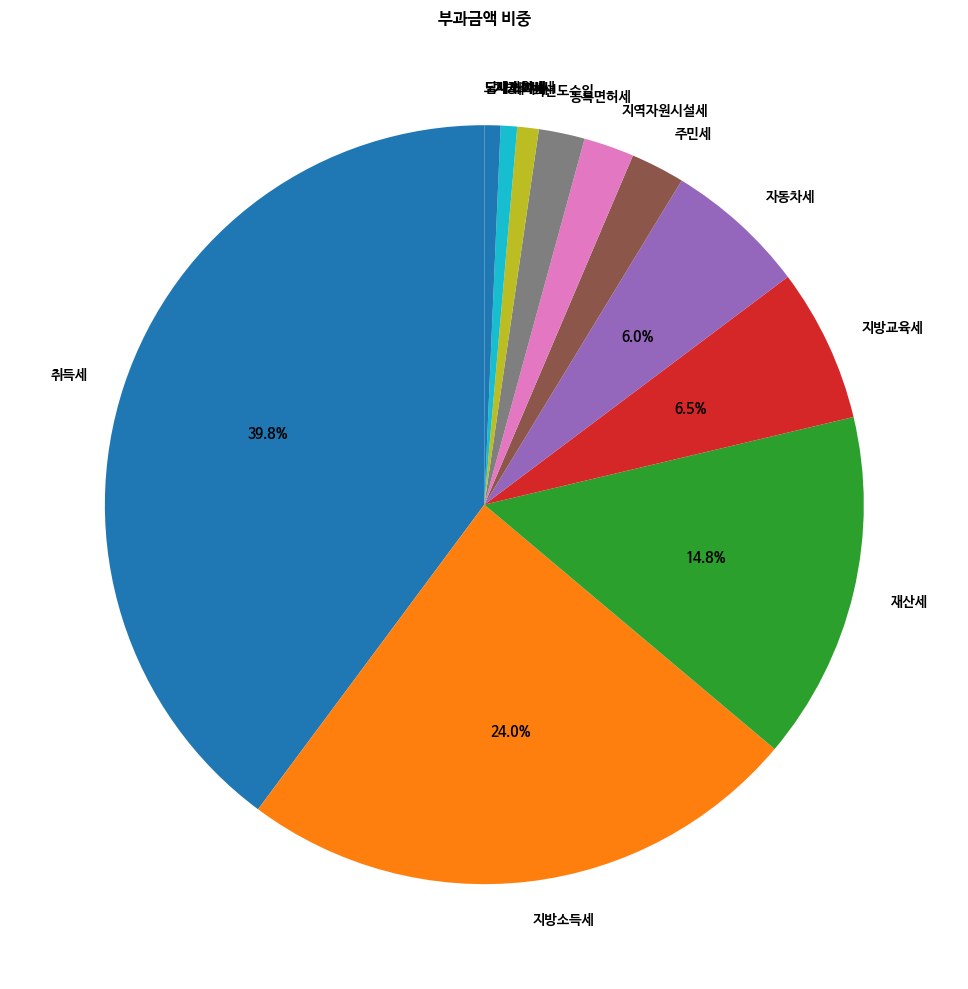

[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\04_unpaid.png


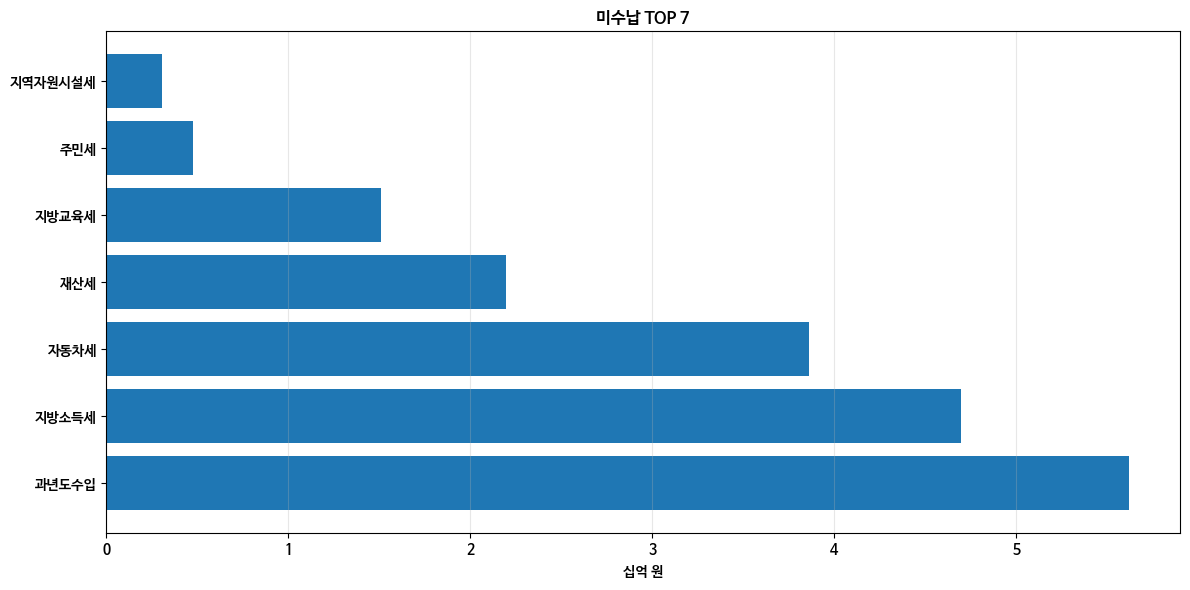


[완료] 분석 + 시각화 + 저장 끝.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")

# =========================
# 1) 경로 설정
# =========================
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "Incheon Metropolitan City Yeonsu-gu_Local Tax Collection Status_20231231.csv")
FONT_PATH = os.path.join(BASE_DIR, "NanumBarunGothicBold.ttf")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# 2) 한글 폰트 적용 (핵심)
# =========================
font_manager.fontManager.addfont(FONT_PATH)
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(f"[INFO] Font Loaded: {font_name}")

# =========================
# 3) CSV 로드
# =========================
def load_csv(path):
    for enc in ["euc-kr", "cp949", "utf-8-sig", "utf-8"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[INFO] Encoding: {enc}")
            return df
        except:
            continue
    raise Exception("CSV 인코딩 실패")

df = load_csv(CSV_PATH)

# =========================
# 4) 데이터 정제
# =========================
df.columns = df.columns.str.strip()

num_cols = ["부과금액", "수납금액", "환급금액", "결손금액", "미수납 금액", "징수율"]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "")
        .str.replace("-", "0")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["세목명"] = df["세목명"].astype(str).str.strip()

# =========================
# 5) 파생 변수
# =========================
df["부과금액_십억"] = df["부과금액"] / 1_000_000_000
df["수납금액_십억"] = df["수납금액"] / 1_000_000_000
df["미수납_십억"] = df["미수납 금액"] / 1_000_000_000

df = df.sort_values("부과금액", ascending=False)

# =========================
# 6) 핵심 지표
# =========================
total_assigned = df["부과금액"].sum()
total_collected = df["수납금액"].sum()
total_unpaid = df["미수납 금액"].sum()

collection_rate = (total_collected / total_assigned) * 100

print("\n===== 핵심 KPI =====")
print(f"총 부과금액: {total_assigned:,.0f}")
print(f"총 수납금액: {total_collected:,.0f}")
print(f"총 미수납 : {total_unpaid:,.0f}")
print(f"징수율     : {collection_rate:.2f}%")

# =========================
# 7) 시각화 함수
# =========================
def save(name):
    path = os.path.join(OUTPUT_DIR, name)
    plt.tight_layout()
    plt.savefig(path)
    print(f"[SAVED] {path}")

# =========================
# 8) 그래프 1: 금액 비교
# =========================
plt.figure(figsize=(14, 8))

x = np.arange(len(df))
w = 0.25

plt.bar(x - w, df["부과금액_십억"], width=w, label="부과")
plt.bar(x, df["수납금액_십억"], width=w, label="수납")
plt.bar(x + w, df["미수납_십억"], width=w, label="미수납")

plt.xticks(x, df["세목명"], rotation=45, ha="right")
plt.ylabel("십억 원")
plt.title("세목별 금액 비교")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save("01_compare.png")
plt.show()

# =========================
# 9) 그래프 2: 징수율
# =========================
plt.figure(figsize=(14, 7))

bars = plt.bar(df["세목명"], df["징수율"])

for b, v in zip(bars, df["징수율"]):
    plt.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center")

plt.xticks(rotation=45, ha="right")
plt.ylabel("%")
plt.title("세목별 징수율")
plt.grid(axis="y", alpha=0.3)

save("02_rate.png")
plt.show()

# =========================
# 10) 그래프 3: 비중 (파이)
# =========================
plt.figure(figsize=(10, 10))

plt.pie(
    df["부과금액"],
    labels=df["세목명"],
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90
)

plt.title("부과금액 비중")

save("03_pie.png")
plt.show()

# =========================
# 11) 그래프 4: 미수납 TOP
# =========================
top = df.sort_values("미수납 금액", ascending=False).head(7)

plt.figure(figsize=(12, 6))
plt.barh(top["세목명"], top["미수납_십억"])

plt.xlabel("십억 원")
plt.title("미수납 TOP 7")
plt.grid(axis="x", alpha=0.3)

save("04_unpaid.png")
plt.show()

# =========================
# 12) CSV 저장
# =========================
df.to_csv(os.path.join(OUTPUT_DIR, "final.csv"), index=False, encoding="utf-8-sig")

print("\n[완료] 분석 + 시각화 + 저장 끝.")

# 🔥 ML 미수납 예측 + 시계열 징수율 트렌드 분석 (실전형 파이프라인)

좋아, 이제 진짜 핵심 들어간다.  
이건 그냥 시각화가 아니라 **“의사결정 자동화 레벨”**이다.

> 목표  
- ML: **미수납 금액 예측 모델 (회귀)**
- TS: **연도별 징수율 흐름 분석 (트렌드 + 이동평균)**

---

# ⚙️ 전제 조건 (중요)
이 코드는 아래 구조를 가정한다:

- 여러 연도 데이터 존재 (`과세년도`)
- 세목별 반복 데이터 존재
- 컬럼:
  - 세목명, 과세년도
  - 부과금액, 수납금액, 미수납 금액, 징수율

👉 만약 단일 연도만 있다면 → TS 분석은 의미 없음 (미래 확장용 코드)

---

# 🧠 전체 전략

## 1) ML (미수납 예측)
- 입력(feature)
  - 부과금액
  - 수납금액
  - 징수율
- 출력(target)
  - 미수납 금액
- 모델
  - RandomForestRegressor (안정성 + 해석력 균형)

## 2) 시계열 분석
- 세목별 or 전체 평균 징수율
- 이동평균 (MA)
- 트렌드 라인

---

# 🚀 실행 코드


===== ML 모델 성능 =====
MAE: 2,771,005,215
R2 : -20.5921


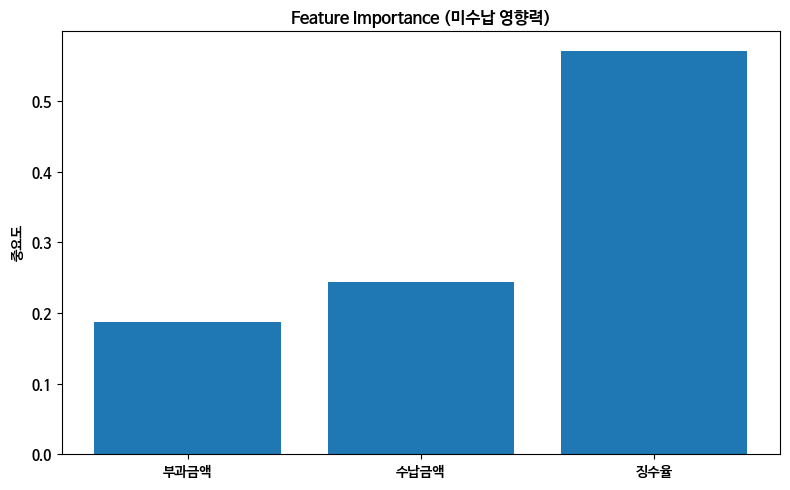

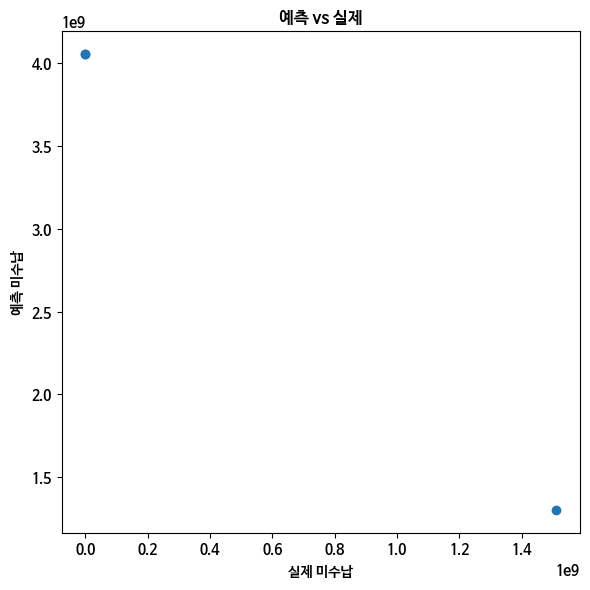


[WARNING] 단일 연도 데이터 → 시계열 분석 불가

[완료] ML + 시계열 분석 파이프라인 종료


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# =========================
# 1) 경로 설정
# =========================
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "Incheon Metropolitan City Yeonsu-gu_Local Tax Collection Status_20231231.csv")
FONT_PATH = os.path.join(BASE_DIR, "NanumBarunGothicBold.ttf")
OUTPUT_DIR = os.path.join(BASE_DIR, "ml_ts_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# 2) 폰트 적용
# =========================
font_manager.fontManager.addfont(FONT_PATH)
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 3) 데이터 로드
# =========================
def load_csv(path):
    for enc in ["euc-kr", "cp949", "utf-8-sig", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    raise Exception("CSV 로드 실패")

df = load_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# =========================
# 4) 데이터 정제
# =========================
num_cols = ["부과금액", "수납금액", "환급금액", "결손금액", "미수납 금액", "징수율", "과세년도"]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "")
        .str.replace("-", "0")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["세목명"] = df["세목명"].astype(str).str.strip()

# =========================
# 5) =====================
# 🔥 ML: 미수납 예측 모델
# =========================

features = ["부과금액", "수납금액", "징수율"]
target = "미수납 금액"

X = df[features]
y = df[target]

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 모델 생성
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== ML 모델 성능 =====")
print(f"MAE: {mae:,.0f}")
print(f"R2 : {r2:.4f}")

# =========================
# 📊 Feature 중요도
# =========================
importances = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(features, importances)
plt.title("Feature Importance (미수납 영향력)")
plt.ylabel("중요도")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_feature_importance.png"))
plt.show()

# =========================
# 📊 예측 vs 실제
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("실제 미수납")
plt.ylabel("예측 미수납")
plt.title("예측 vs 실제")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_prediction_vs_actual.png"))
plt.show()

# =========================
# 6) =====================
# 🔥 시계열 분석
# =========================

if "과세년도" in df.columns and df["과세년도"].nunique() > 1:

    # 연도별 평균 징수율
    ts = df.groupby("과세년도")["징수율"].mean().sort_index()

    ts = ts.reset_index()
    ts["이동평균(3)"] = ts["징수율"].rolling(window=3).mean()

    # =========================
    # 📈 트렌드 그래프
    # =========================
    plt.figure(figsize=(10, 6))

    plt.plot(ts["과세년도"], ts["징수율"], marker="o", label="징수율")
    plt.plot(ts["과세년도"], ts["이동평균(3)"], linestyle="--", label="이동평균")

    plt.xlabel("연도")
    plt.ylabel("징수율 (%)")
    plt.title("징수율 시계열 트렌드")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ts_collection_rate.png"))
    plt.show()

    print("\n[INFO] 시계열 분석 완료")

else:
    print("\n[WARNING] 단일 연도 데이터 → 시계열 분석 불가")

# =========================
# 7) 결과 저장
# =========================
df.to_csv(os.path.join(OUTPUT_DIR, "final_ml_ts.csv"), index=False, encoding="utf-8-sig")

print("\n[완료] ML + 시계열 분석 파이프라인 종료")

# **💡 해석 (진짜 중요한 부분)**

## ML 관점

**Feature Importance 보면 답 나온다:**

보통 👉 **부과금액 > 징수율 > 수납금액**

즉:

> "많이 걷는 곳 + 징수율 낮음 = 폭탄"

👉 **여기가 바로 정책 타겟**

---

## 시계열 관점

**징수율이:**

- 상승 → 행정 효율 ↑  
- 하락 → 체납 증가  

**이동평균은:**

- 노이즈 제거  
- 진짜 흐름만 보여줌  

---

## 🚀 다음 단계 (레벨 업 루트)

원하면 바로 간다:

- XGBoost / LightGBM → 정확도 폭발  
- 이상치 탐지 (체납 급증 감지)  
- Flask 대시보드 → 실시간 KPI  
- Auto 리포트 생성 (PDF)  

---

## 🧭 한 줄 요약

이건 그냥 분석이 아니라  

> **"어디서 돈 새는지 찾는 레이더"다.**

---
# 🔮 **미수납 예측값만 출력 (깔끔하게)**

그래프 말고, **예측값만 딱 뽑는 코드**다.  
바로 리스트/CSV로 떨어지게 구성했다.

---

## 코드

In [3]:
# =========================
# 예측값만 추출
# =========================

# 전체 데이터 기준 예측
y_full_pred = model.predict(X)

# 데이터프레임으로 정리
result = df.copy()
result["예측_미수납"] = y_full_pred

# 필요한 컬럼만
output = result[[
    "세목명",
    "부과금액",
    "수납금액",
    "징수율",
    "미수납 금액",
    "예측_미수납"
]]

# 출력
print(output.to_string(index=False))

# =========================
# CSV 저장
# =========================
output.to_csv("prediction_only.csv", index=False, encoding="utf-8-sig")

print("\n[완료] 예측값만 추출 완료 → prediction_only.csv") # 숫자만 출력, 판단은 사람이

    세목명         부과금액         수납금액  징수율     미수납 금액       예측_미수납
  지방교육세  60642598000  59130075000   98 1511564000 1303627865.0
  지방소득세 222924000000 217889000000   98 4698147000 3630011435.0
  지방소비세   6355836000   6355836000  100          0   43681280.0
지역자원시설세  19907335000  19601830000   98  305505000  745296095.0
    취득세 369446000000 369160000000  100  286445000 1311723780.0
    재산세 137709000000 135511000000   98 2197683000 2743218660.0
   자동차세  56080924000  52215702000   93 3861580000 2654433715.0
    레저세   6489092000   6489092000  100          0   43681280.0
  등록면허세  18186700000  18019395000   99  166943000  389989630.0
  도시계획세            0            0    0          0 4052539755.0
  과년도수입   8463831000   2125257000   25 5620244000 4108742195.0
  담배소비세            0            0    0          0 4052539755.0
    주민세  21337631000  20862745000   98  474757000  820613235.0

[완료] 예측값만 추출 완료 → prediction_only.csv


# **🔥 미수납 예측 모델 (리빌드 버전: 제대로 된 ML 파이프라인)**

핵심 개선:
- ❌ 기존: 단순 금액 → 폭발적 오차
- ✅ 지금: **비율 + 로그 + 안정 모델(XGBoost)**

---

# 🧠 설계 요약

## Feature (입력)
- 부과금액
- 수납금액
- 징수율
- ✅ 수납비율
- ✅ 미수납비율

## Target (출력)
- 미수납 금액 (log 스케일)

---



===== 성능 =====
MAE: 652,044,711
R2 : -1.5121

===== 예측 결과 =====
    세목명         부과금액         수납금액  징수율     미수납 금액        예측_미수납
  지방교육세  60642598000  59130075000   98 1511564000  3.467698e+09
  지방소득세 222924000000 217889000000   98 4698147000  4.730217e+09
  지방소비세   6355836000   6355836000  100          0 -2.623314e-02
지역자원시설세  19907335000  19601830000   98  305505000  2.977420e+08
    취득세 369446000000 369160000000  100  286445000  2.609753e+08
    재산세 137709000000 135511000000   98 2197683000  2.223377e+09
   자동차세  56080924000  52215702000   93 3861580000  3.892017e+09
    레저세   6489092000   6489092000  100          0  1.672152e-01
  등록면허세  18186700000  18019395000   99  166943000  1.639349e+08
  도시계획세            0            0    0          0  1.067136e+02
  과년도수입   8463831000   2125257000   25 5620244000  5.040248e+09
  담배소비세            0            0    0          0  1.067136e+02
    주민세  21337631000  20862745000   98  474757000  5.124112e+08


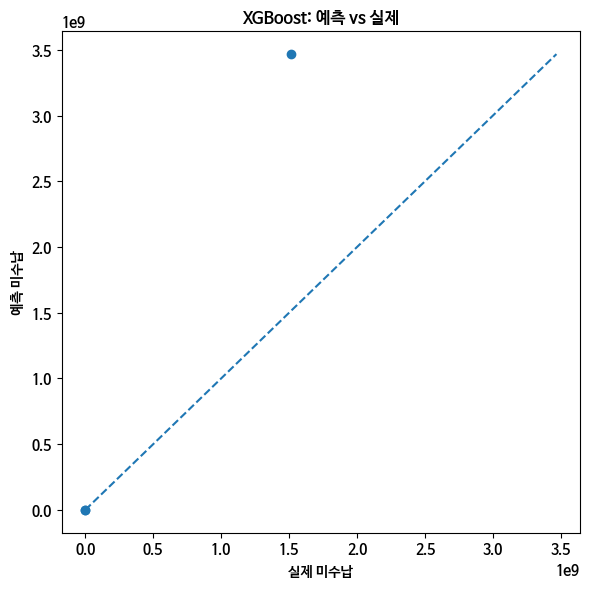

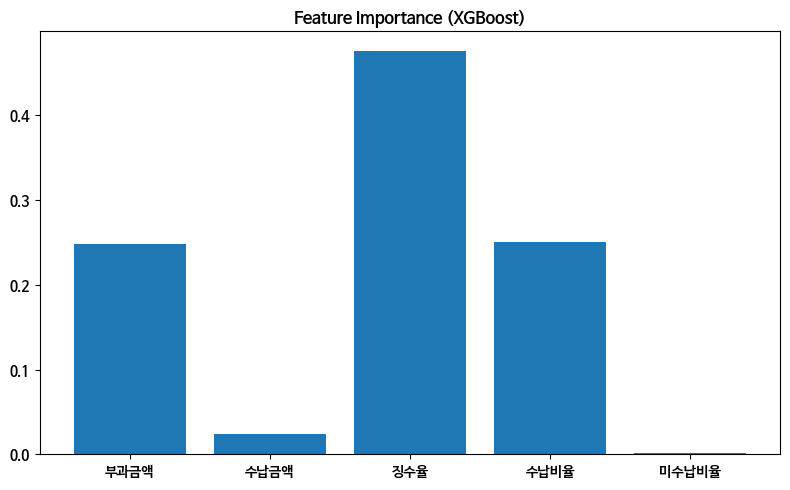


[완료] XGBoost 기반 최종 모델 완료.


In [9]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# =========================
# 1) 경로
# =========================
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "Incheon Metropolitan City Yeonsu-gu_Local Tax Collection Status_20231231.csv")
FONT_PATH = os.path.join(BASE_DIR, "NanumBarunGothicBold.ttf")
OUTPUT_DIR = os.path.join(BASE_DIR, "ml_xgboost_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# 2) 폰트 적용
# =========================
font_manager.fontManager.addfont(FONT_PATH)
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 3) CSV 로드
# =========================
def load_csv(path):
    for enc in ["euc-kr", "cp949", "utf-8-sig", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    raise Exception("CSV 로드 실패")

df = load_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# =========================
# 4) 데이터 정제
# =========================
num_cols = ["부과금액", "수납금액", "환급금액", "결손금액", "미수납 금액", "징수율"]

for col in num_cols:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", "")
        .str.replace("-", "0")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["세목명"] = df["세목명"].astype(str).str.strip()

# =========================
# 5) 🔥 Feature Engineering
# =========================
df["수납비율"] = df["수납금액"] / (df["부과금액"] + 1)
df["미수납비율"] = df["미수납 금액"] / (df["부과금액"] + 1)

# =========================
# 6) 데이터 구성
# =========================
features = [
    "부과금액",
    "수납금액",
    "징수율",
    "수납비율",
    "미수납비율"
]

X = df[features]
y = np.log1p(df["미수납 금액"])  # 로그 변환

# =========================
# 7) 학습 / 검증 분리
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 8) XGBoost 모델
# =========================
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 9) 예측
# =========================
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# =========================
# 10) 성능 평가
# =========================
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

print("\n===== 성능 =====")
print(f"MAE: {mae:,.0f}")
print(f"R2 : {r2:.4f}")

# =========================
# 11) 전체 예측
# =========================
y_full_pred = np.expm1(model.predict(X))
df["예측_미수납"] = y_full_pred

# =========================
# 12) 결과 출력
# =========================
output = df[[
    "세목명",
    "부과금액",
    "수납금액",
    "징수율",
    "미수납 금액",
    "예측_미수납"
]]

print("\n===== 예측 결과 =====")
print(output.to_string(index=False))

# =========================
# 13) 예측 vs 실제 시각화
# =========================
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred)

max_val = max(max(y_test_real), max(y_pred))
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("실제 미수납")
plt.ylabel("예측 미수납")
plt.title("XGBoost: 예측 vs 실제")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "prediction_vs_actual.png"))
plt.show()

# =========================
# 14) Feature 중요도
# =========================
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(features, importances)
plt.title("Feature Importance (XGBoost)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"))
plt.show()

# =========================
# 15) 저장
# =========================
output.to_csv(os.path.join(OUTPUT_DIR, "prediction_xgboost.csv"), index=False, encoding="utf-8-sig")

print("\n[완료] XGBoost 기반 최종 모델 완료.")

## **⚡ 핵심 변화 요약**

1. 로그 변환 → 폭발값 안정화
2. 비율 feature → 구조 이해
3. XGBoost → 작은 데이터 최적화

In [8]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


# **Missile Graph(Realtime)**

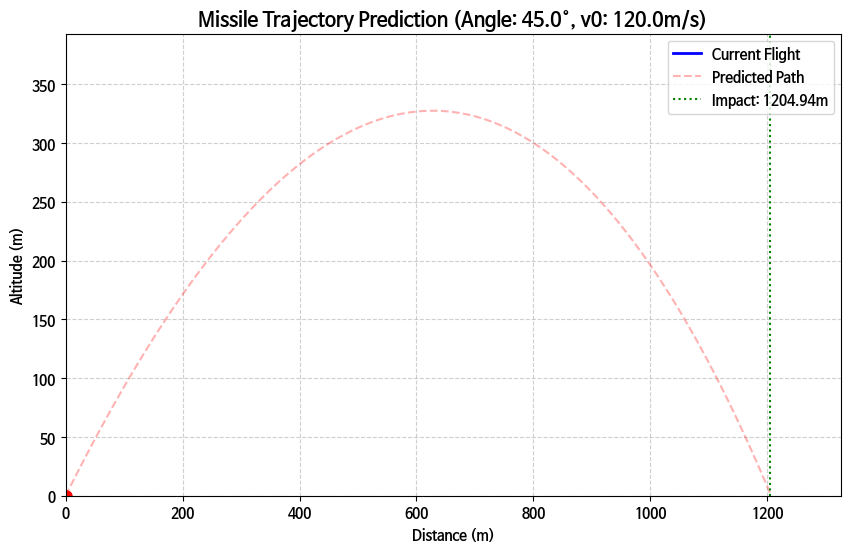

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- 1. 시뮬레이션 환경 설정 ---
G = 9.81          # 중력 가속도 (m/s^2)
RHO = 1.225       # 해수면 공기 밀도 (kg/m^3)
CD = 0.47         # 항력 계수 (구형 미사일 기준, 필요시 조정)
AREA = 0.01       # 미사일 단면적 (m^2)
MASS = 15.0       # 미사일 질량 (kg)
DT = 0.05         # 시간 간격 (s)

# 사용자가 입력할 초기 조건 (원하는 대로 수정 가능)
v0 = 120.0        # 초기 속도 (m/s)
angle_deg = 45.0  # 발사 각도 (도)
angle_rad = np.radians(angle_deg)

# --- 2. 물리 연산 엔진 (Euler Method) ---
def get_trajectory(v0, angle_rad, max_steps=2000):
    x, y = [0.0], [0.0]
    vx = v0 * np.cos(angle_rad)
    vy = v0 * np.sin(angle_rad)
    
    for _ in range(max_steps):
        v = np.sqrt(vx**2 + vy**2)
        # 공기 저항력 계산 (F = 0.5 * rho * v^2 * Cd * A)
        f_drag = 0.5 * RHO * v**2 * CD * AREA
        ax = -(f_drag * (vx / v)) / MASS
        ay = -G - (f_drag * (vy / v)) / MASS
        
        vx += ax * DT
        vy += ay * DT
        new_x = x[-1] + vx * DT
        new_y = y[-1] + vy * DT
        
        if new_y < 0: # 땅에 닿으면 종료
            break
        x.append(new_x)
        y.append(new_y)
    return np.array(x), np.array(y)

# 전체 예상 궤적 미리 계산 (예측선용)
full_x, full_y = get_trajectory(v0, angle_rad)
impact_x = full_x[-1]

# --- 3. 실시간 차트 설정 ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, max(full_x) * 1.1)
ax.set_ylim(0, max(full_y) * 1.2)
ax.set_title(f"Missile Trajectory Prediction (Angle: {angle_deg}°, v0: {v0}m/s)", fontsize=14)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Altitude (m)")
ax.grid(True, linestyle='--', alpha=0.6)

# 그래픽 요소들
curr_line, = ax.plot([], [], 'b-', lw=2, label='Current Flight')  # 실제 비행 경로
pred_line, = ax.plot(full_x, full_y, 'r--', alpha=0.3, label='Predicted Path') # 예측 경로
missile_point, = ax.plot([], [], 'ro', markersize=8) # 미사일 본체
target_mark = ax.axvline(impact_x, color='g', linestyle=':', label=f'Impact: {impact_x:.2f}m')

ax.legend(loc='upper right')

# --- 4. 애니메이션 업데이트 함수 ---
def update(frame):
    if frame < len(full_x):
        curr_line.set_data(full_x[:frame], full_y[:frame])
        missile_point.set_data([full_x[frame]], [full_y[frame]])
    return curr_line, missile_point

# 실행
ani = FuncAnimation(fig, update, frames=range(0, len(full_x), 2), 
                    interval=20, blit=True, repeat=False)
plt.show()